In [20]:
import numpy as np
from StatTools.generators.ndfnoise_generator import ndfnoise
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

def gen_poisson_bg(frame_shape, num_photons= 1000, qe = 0.6, sense = 0.36, bitdepth = 8):
    max_adu = int(2**bitdepth - 1)
 
    mu_p = np.ones(frame_shape) * num_photons
    poisson = np.random.poisson(lam=mu_p, size=frame_shape)
    electrons = np.round(poisson * qe)
    adu = (electrons * sense).astype(np.int32)
    adu[adu > max_adu] = max_adu
    return adu.astype(np.uint8)

def gen_traj(frame_num: int, ants_num: int, frame_shape: tuple, margin:int = 10,
             hurst_move: float = 0.5, hurst_species: float = 0.5, 
             start_point = None):
    

    dx = ndfnoise(shape=(frame_num, ants_num), hurst=[hurst_move, hurst_species], normalize=True, dtype=np.float32)
    dy = ndfnoise(shape=(frame_num, ants_num), hurst=[hurst_move, hurst_species], normalize=True, dtype=np.float32)

    x = dx.round().cumsum(axis=0).astype(np.int32)
    y = dy.round().cumsum(axis=0).astype(np.int32)

    if start_point is None:
        start_x = np.random.randint(margin, frame_shape[1] - margin, (ants_num,))
        start_y = np.random.randint(margin, frame_shape[0] - margin, (ants_num,))
        start_point = np.stack([start_x, start_y], axis=1)

    trajectories = np.stack([x, y], axis=2)
    trajectories = trajectories + start_point

    return trajectories

def draw_traj(trajectories, frame_shape: tuple, ants_num: int):
    
    colors = sns.color_palette(palette='bright', n_colors=ants_num)
    colors = [tuple([int(c*255) for c in color]) for color in colors]

    bg = np.zeros(shape=(*frame_shape, 3), dtype=np.uint8)
    trajs = []
    for ant in range(trajectories.shape[1]):
        trajs.append(np.array([np.array(traj) for traj in trajectories[:, ant]]))
    for ant, color in  zip(trajs, colors):

        cv2.polylines(bg, [ant], isClosed=False, color=color, thickness=2)

    plt.imshow(cv2.cvtColor(bg, cv2.COLOR_BGR2RGB))
    plt.show()

def draw_ants_with_direction(trajectories, output_path:str, frame_num: int, ants_num: int, frame_shape: tuple, ant_length = 5, ant_width=2, smooth_window:int=3):
    
    
    # Define codec and create VideoWriter object
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    frame_size = (frame_shape[1], frame_shape[0]) 
    out = cv2.VideoWriter(output_path, fourcc, 24.0, frame_size, isColor=True)
    for frame_idx in range(frame_num):
        frame = gen_poisson_bg(frame_shape, sense=0.43)
        # frame = np.ones((*frame_shape, 3), dtype=np.uint8)*255
        
        for ant_idx in range(ants_num):
            
            x, y = trajectories[frame_idx, ant_idx]
            start_index = max(0, frame_idx-smooth_window)
            dx = x - trajectories[start_index:frame_idx, ant_idx, 0].mean()
            dy = y - trajectories[start_index:frame_idx, ant_idx, 1].mean()
            angle = np.arctan2(dy, dx) * 180 / np.pi
            
            center = (int(x), int(y))
            axes = (ant_length, ant_width)
            cv2.ellipse(frame, center, axes, angle, 0, 360, 
                       (100, 100, 100), -1)
        frame = cv2.GaussianBlur(frame, ksize=(7,7), sigmaX=1.0)
        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        out.write(frame)
        cv2.imshow('frame', frame)
        if cv2.waitKey(1) & 0xFF == 27:
            cv2.destroyAllWindows()
            out.release()
            break
        
    out.release()
    cv2.destroyAllWindows()

c:\Users\akhiyarov.si\Documents\asp\NMOT\StatTools\generators\ndfnoise_generator.py:51: RuntimeWarning: divide by zero encountered in reciprocal
  S *= np.abs(f.reshape(reshape)) ** (-(hurst[i] - 0.5))
c:\Users\akhiyarov.si\Documents\asp\NMOT\StatTools\generators\ndfnoise_generator.py:55: RuntimeWarning: invalid value encountered in multiply
  S *= np.abs(f_last.reshape((1,) * (dim - 1) + (-1,))) ** (-(hurst[-1] - 0.5))


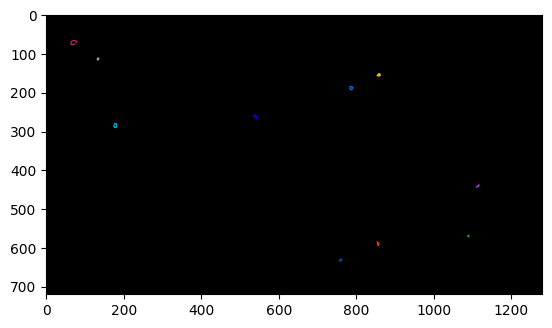

In [21]:

np.random.seed(42)

config = {
'frame_num' : 20,
'frame_shape' : (720, 1280),
'margin': 50,
'hurst_move': 1.5,
'hurst_species': 0.1,
'ants_num' : 10,
'start_point' : None
}
trajectories = gen_traj(**config)
draw_traj(trajectories, config['frame_shape'],  config['ants_num'])



In [27]:
flat_trajectories = trajectories.reshape(-1, 2)

frame_indices = np.repeat(np.arange(trajectories.shape[0]), trajectories.shape[1])
ant_indices = np.tile(np.arange(trajectories.shape[1]), trajectories.shape[0])

df = pd.DataFrame({
    'frame': frame_indices,
    'ant_id': ant_indices,
    'x': flat_trajectories[:, 0],
    'y': flat_trajectories[:, 1]
})
df = df.sort_values(['ant_id','frame'])
df.to_csv('gen_ants_gt.csv', index=False)

In [6]:
draw_ants_with_direction(trajectories, output_path = 'gen_ants.mp4', frame_num=config['frame_num'], ants_num=config['ants_num'], frame_shape=config['frame_shape'], ant_length = 3, ant_width=1, smooth_window=5)

C:\Users\akhiyarov.si\AppData\Local\Temp\ipykernel_17100\2105869773.py:71: RuntimeWarning: Mean of empty slice.
  dx = x - trajectories[start_index:frame_idx, ant_idx, 0].mean()
c:\Users\akhiyarov.si\AppData\Local\miniconda3\envs\asdc\Lib\site-packages\numpy\_core\_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
C:\Users\akhiyarov.si\AppData\Local\Temp\ipykernel_17100\2105869773.py:72: RuntimeWarning: Mean of empty slice.
  dy = y - trajectories[start_index:frame_idx, ant_idx, 1].mean()
